<a href="https://colab.research.google.com/github/ZeeMurphy/Data_205_Capstone_Project/blob/main/eda/notebooks/Cognitive_Decline_EDA_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cognitive Decline Risk Factors in U.S. Older Adults
## Data Ingestion and Exploratory Data Analysis (EDA)

**Dataset:** CDC BRFSS — Alzheimer's Disease and Healthy Aging Data (2015–2022)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

The goal of this project is to explore what health and behavioral factors are linked to cognitive decline (memory loss) in older adults across U.S. states. This notebook covers loading and cleaning the data, then exploring it through charts and statistics to answer my research questions.

**Research questions I'm exploring here:**
- RQ1: Which states have the highest cognitive decline rates?
- RQ2–RQ5: How do depression, physical inactivity, poor health, and disability relate to cognitive decline?
- RQ8: Does cognitive decline differ between the 50–64 and 65+ age groups?
- RQ9: Are early-stage memory complaints linked to more severe cognitive decline?

*(RQ6, RQ7, RQ10 require Census income/education data — coming in the next phase)*

## Part 1: Load and Clean the Data

**Data Source:** CDC BRFSS Alzheimer's Disease and Healthy Aging Data (2015–2022)  
Loaded live using the CDC Socrata SODA2 API — no file upload or API key needed.

A few things to know about this API:
- It takes about 30–60 seconds to load since it downloads ~140MB from the CDC website
- The API returns all column names in lowercase, so we rename them to match the original CDC CSV format
- We lock the data to 2015–2022 using a year filter so results stay consistent even if CDC adds new years later
- The default API limit is 1,000 rows — we override this with `$limit=300000` to get all 284,142 rows    
The dataset has 284,142 rows and 31 columns. Each row represents one survey answer for one question, in one location, in one year, for one age subgroup. This is called long format, I'll reshape it later.(In long format, each row contains only one single measurement. So instead of having one row per state with all questions as columns, each question gets its own separate row. For example, if Alabama reported 10 different survey questions in 2019, that would be 10 separate rows in the dataset rather than one row with 10 columns. We will reshape it into wide format later so each state-year becomes one row with all questions as columns, which is what we need for correlation analysis.)

In [ ]:
CDC_URL = "https://data.cdc.gov/resource/hfr9-rurv.csv?$limit=300000"
df_test = pd.read_csv(CDC_URL, engine="python", on_bad_lines="skip")
print(df_test.columns.tolist())

['rowid', 'yearstart', 'yearend', 'locationabbr', 'locationdesc', 'datasource', 'class', 'topic', 'question', 'data_value_unit', 'datavaluetypeid', 'data_value_type', 'data_value', 'data_value_alt', 'data_value_footnote_symbol', 'data_value_footnote', 'low_confidence_limit', 'high_confidence_limit', 'stratificationcategory1', 'stratification1', 'stratificationcategory2', 'stratification2', 'geolocation', 'classid', 'topicid', 'questionid', 'locationid', 'stratificationcategoryid1', 'stratificationid1', 'stratificationcategoryid2', 'stratificationid2']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load CDC dataset live from CDC website (SODA2 API, no key needed)
# Source: data.cdc.gov/Healthy-Aging/Alzheimer-s-Disease-and-Healthy-Aging-Data/hfr9-rurv
CDC_URL = "https://data.cdc.gov/resource/hfr9-rurv.csv?$limit=300000"
df = pd.read_csv(CDC_URL, engine="python", on_bad_lines="skip")

# The API returns lowercase column names but our code expects mixed case
# This line renames them to match the original CSV format exactly
df.columns = [
    'RowId', 'YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc',
    'Datasource', 'Class', 'Topic', 'Question', 'Data_Value_Unit',
    'DataValueTypeID', 'Data_Value_Type', 'Data_Value', 'Data_Value_Alt',
    'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
    'Low_Confidence_Limit', 'High_Confidence_Limit',
    'StratificationCategory1', 'Stratification1',
    'StratificationCategory2', 'Stratification2', 'Geolocation',
    'ClassID', 'TopicID', 'QuestionID', 'LocationID',
    'StratificationCategoryID1', 'StratificationID1',
    'StratificationCategoryID2', 'StratificationID2'
]

# Convert YearStart to numeric — API returns it as text
df["YearStart"] = pd.to_numeric(df["YearStart"], errors="coerce")

# Lock to 2015-2022 so results don't change if CDC adds new years later
df = df[df["YearStart"].between(2015, 2022)]

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 284,142 | Columns: 31


,RowId,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,...,Stratification2,Geolocation,ClassID,TopicID,QuestionID,LocationID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2
0,BRFSS~2015~2015~66~Q35~TOC03~AGE~SEX,2015,2015,GU,Guam,BRFSS,Overall Health,Recent activity limitations in past month,Mean number of days with activity limitations ...,Number,...,Female,POINT (144.793731 13.444304),C01,TOC03,Q35,66,AGE,AGE_OVERALL,SEX,FEMALE
1,BRFSS~2015~2015~25~Q27~TMC03~AGE~SEX,2015,2015,MA,Massachusetts,BRFSS,Mental Health,Lifetime diagnosis of depression,Percentage of older adults with a lifetime dia...,%,...,Male,POINT (-72.08269067499964 42.27687047000046),C05,TMC03,Q27,25,AGE,65PLUS,SEX,MALE
2,BRFSS~2015~2015~9002~Q43~TOC11~AGE~SEX,2015,2015,MDW,Midwest,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,Male,NaN,C01,TOC11,Q43,9002,AGE,5064,SEX,MALE
3,BRFSS~2015~2015~27~Q03~TMC01~AGE~SEX,2015,2015,MN,Minnesota,BRFSS,Mental Health,Frequent mental distress,Percentage of older adults who are experiencin...,%,...,Male,POINT (-94.79420050299967 46.35564873600049),C05,TMC01,Q03,27,AGE,AGE_OVERALL,SEX,MALE
4,BRFSS~2015~2015~29~Q43~TOC11~AGE~OVERALL,2015,2015,MO,Missouri,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,NaN,POINT (-92.56630005299968 38.635790776000476),C01,TOC11,Q43,29,AGE,AGE_OVERALL,OVERALL,OVERALL


In [ ]:
# Check data types and see which columns have missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284142 entries, 0 to 284141
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RowId                       284142 non-null  object 
 1   YearStart                   284142 non-null  int64  
 2   YearEnd                     284142 non-null  int64  
 3   LocationAbbr                284142 non-null  object 
 4   LocationDesc                284142 non-null  object 
 5   Datasource                  284142 non-null  object 
 6   Class                       284142 non-null  object 
 7   Topic                       284142 non-null  object 
 8   Question                    284142 non-null  object 
 9   Data_Value_Unit             284142 non-null  object 
 10  DataValueTypeID             284142 non-null  object 
 11  Data_Value_Type             284142 non-null  object 
 12  Data_Value                  192808 non-null  float64
 13  Data_Value_Alt

In [ ]:
# --- Data Cleaning ---
# Step 1: Make a copy so I don't change the original
df_clean = df.copy()

# Step 2: Replace different versions of missing values with one standard (pd.NA)
df_clean = df_clean.replace(["", " ", "NA", "N/A"], pd.NA)

# Step 3: Convert Data_Value and YearStart to numbers
# errors='coerce' turns anything that can't be converted into NaN instead of crashing
df_clean["Data_Value"] = pd.to_numeric(df_clean["Data_Value"], errors="coerce")
df_clean["YearStart"]  = pd.to_numeric(df_clean["YearStart"],  errors="coerce")

# Step 4: Drop rows missing the value or the year — they can't be used in any analysis
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Data_Value", "YearStart"]).copy()

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows dropped:         {before - len(df_clean):,}")

Rows before cleaning: 284,142
Rows after cleaning:  192,808
Rows dropped:         91,334


In [ ]:
# Quick look at what's in the key columns
print("Unique locations:", df_clean['LocationAbbr'].nunique())
print(sorted(df_clean['LocationAbbr'].unique()))
print("\nAge group options:", df_clean['Stratification1'].unique())
print("\nHealth topic classes:", sorted(df_clean['Class'].unique()))

Unique locations: 59
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'MDW', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NRE', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'SOU', 'TN', 'TX', 'US', 'UT', 'VA', 'VI', 'VT', 'WA', 'WEST', 'WI', 'WV', 'WY']

Age group options: ['Overall' '65 years or older' '50-64 years']

Health topic classes: ['Caregiving', 'Cognitive Decline', 'Mental Health', 'Nutrition/Physical Activity/Obesity', 'Overall Health', 'Screenings and Vaccines', 'Smoking and Alcohol Use']


The dataset includes 59 locations — not just the 50 states. It also includes U.S. territories like Puerto Rico and Guam, plus regional averages for the Midwest, South, Northeast, and West. I'll filter these out and keep only the 50 states + D.C. for my state-level analysis.

Each question also appears three times per state-year: once for the full 'Overall' group, once for ages 50–64, and once for ages 65+. I'll use 'Overall' for most analysis to avoid counting the same state three times.

In [ ]:
# Check the exact wording of cognitive decline questions — need exact strings for filtering
print("Cognitive Decline questions:")
for q in df_clean[df_clean['Class'] == 'Cognitive Decline']['Question'].unique():
    print(" -", q)

Cognitive Decline questions:
 - Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores
 - Percentage of older adults with subjective cognitive decline or memory loss who reported talking with a health care professional about it
 - Percentage of older adults who reported subjective cognitive decline or memory loss that is happening more often or is getting worse in the preceding 12 months
 - Percentage of older adults who reported that as a result of subjective cognitive decline or memory loss that they need assistance with day-to-day activities


## Part 2: Check Data Coverage by Year

Before building my analysis dataset, I want to check how many states reported cognitive decline data each year. The cognitive decline module in BRFSS is optional — states choose whether to include it. This means some years have much less data than others, which is an important limitation to keep in mind.

In [ ]:
cognitive_questions = [
    "Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores",
    "Percentage of older adults who reported subjective cognitive decline or memory loss that is happening more often or is getting worse in the preceding 12 months",
    "Percentage of older adults who reported that as a result of subjective cognitive decline or memory loss that they need assistance with day-to-day activities",
    "Percentage of older adults with subjective cognitive decline or memory loss who reported talking with a health care professional about it"
]

# Non-state locations to exclude
exclude = ["US", "NRE", "MDW", "SOU", "WEST"]

coverage = df_clean[
    (df_clean["Question"].isin(cognitive_questions)) &
    (~df_clean["LocationAbbr"].isin(exclude)) &
    (df_clean["Stratification1"] == "Overall")
].groupby(["Question", "YearStart"])["LocationAbbr"].nunique().unstack(fill_value=0)

coverage.index = ["Interferes with activities", "Getting worse", "Needs assistance", "Talked to doctor"]
print("States reporting each cognitive decline question per year:")
print(coverage.to_string())

States reporting each cognitive decline question per year:
YearStart                   2015  2016  2017  2018  2019  2020  2021  2022
Interferes with activities    35    21    10     6    49    23    15    18
Getting worse                 35    21    10     6    49    23    15    18
Needs assistance              35    21    10     6    49    23    15    18
Talked to doctor              35    21    10     6    49    23    15    18


Coverage dropped sharply in 2017–2018 (only 10 and 6 states), then recovered in 2019 (49 states). This means year-to-year comparisons need to be interpreted carefully — the national average in 2018 is based on only 6 states, which may not represent the whole country.

## Part 3: Define Variables and Build Analysis Dataset

I'm selecting one cognitive decline question as my main outcome (target), plus six health and behavioral variables as predictors. Then I'll filter and reshape the data into wide format — one row per state per year, with each variable as its own column.

In [ ]:
# Main outcome variable (target)
target = "Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores"

# The other three cognitive decline questions (used in RQ9)
q_worse      = "Percentage of older adults who reported subjective cognitive decline or memory loss that is happening more often or is getting worse in the preceding 12 months"
q_assistance = "Percentage of older adults who reported that as a result of subjective cognitive decline or memory loss that they need assistance with day-to-day activities"
q_talked     = "Percentage of older adults with subjective cognitive decline or memory loss who reported talking with a health care professional about it"

# Six risk factor variables (predictors for RQ2–RQ5)
risk_factors = [
    "Percentage of older adults with a lifetime diagnosis of depression",
    "Percentage of older adults who are experiencing frequent mental distress",
    "Percentage of older adults who have not had any leisure time physical activity in the past month",
    'Percentage of older adults who self-reported that their health is "fair" or "poor"',
    "Physically unhealthy days (mean number of days in past month)",
    "Percentage of older adults who report having a disability (includes limitations related to sensory or mobility impairments or a physical, mental, or emotional condition)"
]

# Short names for chart labels
short_names = {
    target: "Cognitive Decline (%)",
    q_worse: "Getting Worse",
    q_assistance: "Needs Assistance",
    q_talked: "Talked to Doctor",
    'Percentage of older adults who self-reported that their health is "fair" or "poor"': "Poor Health",
    "Percentage of older adults who have not had any leisure time physical activity in the past month": "Physical Inactivity",
    "Percentage of older adults who report having a disability (includes limitations related to sensory or mobility impairments or a physical, mental, or emotional condition)": "Disability",
    "Percentage of older adults who are experiencing frequent mental distress": "Mental Distress",
    "Physically unhealthy days (mean number of days in past month)": "Unhealthy Days",
    "Percentage of older adults with a lifetime diagnosis of depression": "Depression"
}

# U.S. states + DC only
us_states = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN',
    'IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV',
    'NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',
    'TX','UT','VT','VA','WA','WV','WI','WY','DC'
]

print("Variables set up.")

Variables set up.


In [ ]:
# Filter to only the questions I need, Overall age group, and U.S. states only
# Note: filtering to states only is important — without this, Puerto Rico and
# regional averages like 'South' would appear as rows in my charts
all_questions = [target] + risk_factors

df_filtered = df_clean[
    (df_clean["Question"].isin(all_questions)) &
    (df_clean["Stratification1"] == "Overall") &
    (df_clean["LocationAbbr"].isin(us_states))
].copy()

# Reshape from long to wide format
# Each row = one state + one year, each question becomes its own column
# aggfunc='mean' averages across the sex/race breakdowns that exist within 'Overall'
pivot = df_filtered.pivot_table(
    index=["LocationAbbr", "LocationDesc", "YearStart"],
    columns="Question",
    values="Data_Value",
    aggfunc="mean"
).reset_index()
pivot.columns.name = None

print(f"Analysis dataset shape: {pivot.shape}")
print(f"This means {pivot.shape[0]} state-year combinations across {pivot['LocationAbbr'].nunique()} states")
pivot.head(3)

Analysis dataset shape: (406, 10)
This means 406 state-year combinations across 51 states


,LocationAbbr,LocationDesc,YearStart,Percentage of older adults who are experiencing frequent mental distress,Percentage of older adults who have not had any leisure time physical activity in the past month,"Percentage of older adults who report having a disability (includes limitations related to sensory or mobility impairments or a physical, mental, or emotional condition)",Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores,"Percentage of older adults who self-reported that their health is ""fair"" or ""poor""",Percentage of older adults with a lifetime diagnosis of depression,Physically unhealthy days (mean number of days in past month)
0,AK,Alaska,2015,9.24,31.04,NaN,NaN,20.98,16.68,4.84
1,AK,Alaska,2016,9.56,24.60,30.24,29.475,22.20,12.98,5.74
2,AK,Alaska,2017,7.10,26.36,28.66,NaN,21.44,15.84,5.18


## Part 4: Missing Value Analysis

Now I'll check how much data is missing in the pivot table. A quick note on why the numbers might look small: the missing percentages are calculated out of **406 state-year rows**, not the original 284,142 rows. After pivoting, each row represents one state in one year, so there are only about 406 possible combinations (51 states × 8 years).

The cognitive decline variable has the most missing data because it comes from an **optional** BRFSS module, states choose whether to run it each year. The other variables (depression, physical inactivity, poor health) come from **core** modules that nearly every state runs every year, which is why they have almost no missing data.

In [ ]:
# Count missing values per column
missing = pd.DataFrame({
    'Missing Count': pivot.isna().sum(),
    'Missing %': (pivot.isna().mean() * 100).round(1)
})
missing.index = [short_names.get(c, c) for c in missing.index]
print("Missing values (out of", len(pivot), "state-year rows):")
missing[missing['Missing Count'] > 0]

Missing values (out of 406 state-year rows):


,Missing Count,Missing %
Disability,51,12.6
Cognitive Decline (%),233,57.4


In [ ]:
# Drop rows where the main cognitive decline variable is missing
# I keep rows where only a risk factor is missing — those can still be used in some charts
before = len(pivot)
pivot_clean = pivot.dropna(subset=[target]).copy()

print(f"Rows before: {before}  |  Rows after: {len(pivot_clean)}  |  Dropped: {before - len(pivot_clean)}")
print(f"States with cognitive decline data: {pivot_clean['LocationDesc'].nunique()}")
print(f"Years covered: {sorted(pivot_clean['YearStart'].unique())}")

Rows before: 406  |  Rows after: 173  |  Dropped: 233
States with cognitive decline data: 51
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


## Part 5: Descriptive Statistics

Basic summary statistics for all the variables I'll be analyzing.

In [ ]:
# Summary statistics — only for the analysis variables, not YearStart or location names
analysis_cols = [c for c in [target] + risk_factors if c in pivot_clean.columns]

stats = pivot_clean[analysis_cols].describe().T.round(2)
stats.index = [short_names.get(c, c) for c in stats.index]
stats

,count,mean,std,min,25%,50%,75%,max
Cognitive Decline (%),173.0,36.69,6.87,22.42,31.53,35.92,41.13,53.10
Depression,173.0,18.16,3.33,12.24,15.77,18.05,20.42,28.44
Mental Distress,173.0,11.05,2.06,6.15,9.53,10.98,12.58,16.92
Physical Inactivity,173.0,30.31,5.14,21.28,26.42,30.14,33.37,45.74
Poor Health,173.0,25.44,4.78,13.68,22.20,25.69,27.88,38.48
Unhealthy Days,173.0,5.30,0.87,3.23,4.70,5.32,5.82,7.60
Disability,139.0,37.60,5.44,27.47,34.15,36.90,40.25,53.52


## Part 6: RQ1 — Which States Have the Highest Cognitive Decline?

I'm calculating each state's average cognitive decline rate across all the years it reported. States reported in different years, so the averages are based on different numbers of observations,  but each state's average only uses years where it actually participated, so no data is being made up or filled in for missing years.

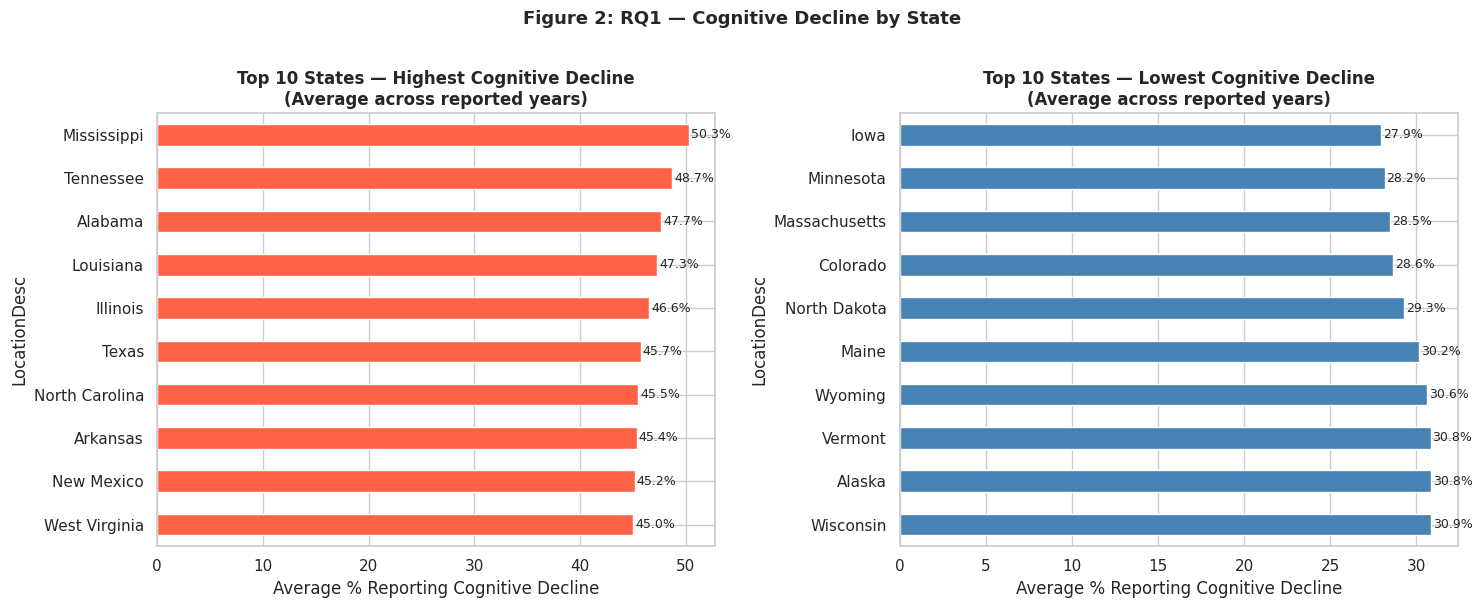

In [ ]:
# Average cognitive decline per state (only years with actual data)
state_avg = pivot_clean.groupby("LocationDesc")[target].mean().sort_values(ascending=False)

top10    = state_avg.head(10).sort_values()
bottom10 = state_avg.tail(10).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top10.plot(kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Top 10 States — Highest Cognitive Decline\n(Average across reported years)', fontweight='bold')
axes[0].set_xlabel('Average % Reporting Cognitive Decline')
for i, v in enumerate(top10.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

bottom10.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 States — Lowest Cognitive Decline\n(Average across reported years)', fontweight='bold')
axes[1].set_xlabel('Average % Reporting Cognitive Decline')
for i, v in enumerate(bottom10.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Figure 2: RQ1 — Cognitive Decline by State', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Southern states (Mississippi, Tennessee, Alabama, Louisiana) have the highest rates, while Midwest and New England states (Iowa, Minnesota, Massachusetts, Colorado) have the lowest. The gap is nearly 2x between the highest and lowest states.

## Part 7: RQ8 — Does Age Group Matter?

Here I compare cognitive decline rates between the 50–64 age group and the 65+ age group. The BRFSS data already has this broken down by age, so I can use that directly.

In [ ]:
# Build age group comparison using the BRFSS stratification column
age_df = df_clean[
    (df_clean["Question"] == target) &
    (df_clean["LocationAbbr"].isin(us_states)) &
    (df_clean["Stratification1"].isin(["50-64 years", "65 years or older"]))
].copy()

age_pivot = age_df.pivot_table(
    index=["LocationAbbr", "LocationDesc", "YearStart"],
    columns="Stratification1",
    values="Data_Value",
    aggfunc="mean"
).reset_index()
age_pivot.columns.name = None

# Compare average rates by age group
avg_by_group = age_pivot[["50-64 years", "65 years or older"]].mean()
print("Average cognitive decline rate by age group:")
print(avg_by_group.round(2))

r_age = age_pivot["50-64 years"].corr(age_pivot["65 years or older"])
print(f"\nCorrelation between age groups: r = {r_age:.2f}")

Average cognitive decline rate by age group:
50-64 years          43.03
65 years or older    29.95
dtype: float64

Correlation between age groups: r = 0.48


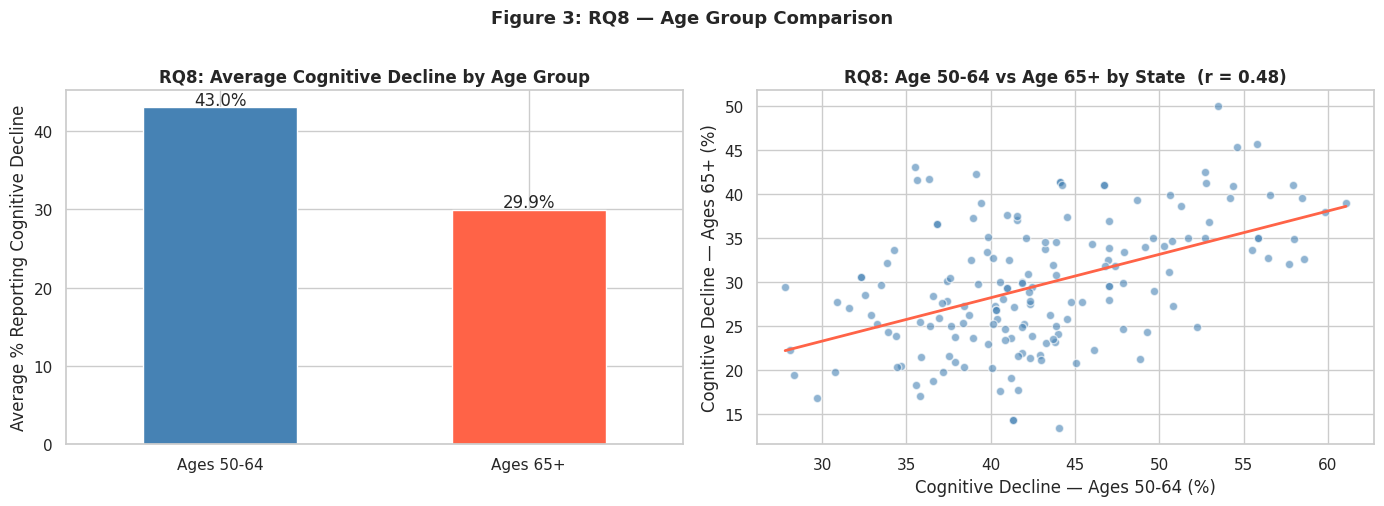

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: average rate by age group
avg_by_group.index = ['Ages 50-64', 'Ages 65+']
avg_by_group.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('RQ8: Average Cognitive Decline by Age Group', fontweight='bold')
axes[0].set_ylabel('Average % Reporting Cognitive Decline')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(avg_by_group.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center')

# Scatter: does the 50-64 rate predict the 65+ rate across states?
age_clean = age_pivot.dropna(subset=["50-64 years", "65 years or older"])
axes[1].scatter(age_clean["50-64 years"], age_clean["65 years or older"],
                color='steelblue', alpha=0.6, edgecolor='white')
m, b = np.polyfit(age_clean["50-64 years"], age_clean["65 years or older"], 1)
x_line = np.linspace(age_clean["50-64 years"].min(), age_clean["50-64 years"].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='tomato', linewidth=2)
axes[1].set_xlabel('Cognitive Decline — Ages 50-64 (%)')
axes[1].set_ylabel('Cognitive Decline — Ages 65+ (%)')
axes[1].set_title(f'RQ8: Age 50-64 vs Age 65+ by State  (r = {r_age:.2f})', fontweight='bold')

plt.suptitle('Figure 3: RQ8 — Age Group Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part 8: RQ9 — Early vs Severe Cognitive Decline

The dataset has four different cognitive decline questions. I'm treating two as "early stage" (getting worse, talked to a doctor) and two as more severe (interferes with activities, needs help with daily tasks). I want to see if states with high early-stage rates also tend to have high severe rates.

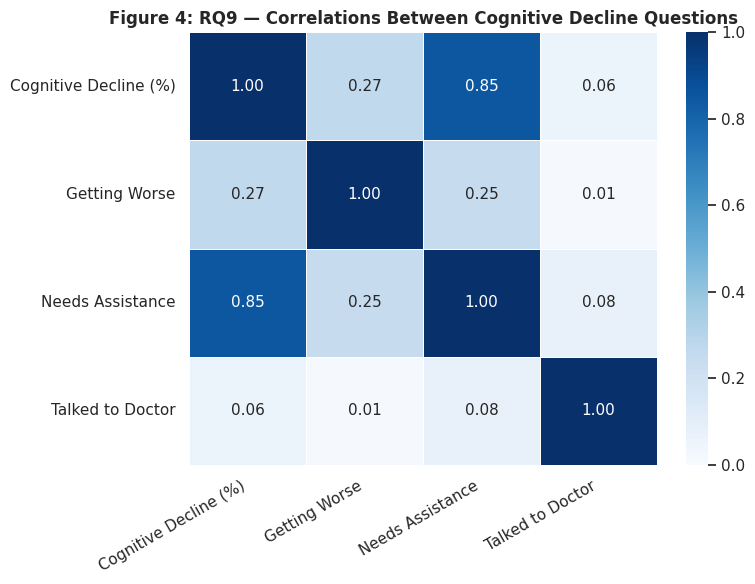

In [ ]:
# Build dataset with all four cognitive decline questions
all_cog = [target, q_worse, q_assistance, q_talked]

pivot_cog = df_clean[
    (df_clean["Question"].isin(all_cog)) &
    (df_clean["Stratification1"] == "Overall") &
    (df_clean["LocationAbbr"].isin(us_states))
].pivot_table(
    index=["LocationAbbr", "LocationDesc", "YearStart"],
    columns="Question",
    values="Data_Value",
    aggfunc="mean"
).reset_index()
pivot_cog.columns.name = None

# Correlation heatmap between all four measures
cog_corr = pivot_cog[[c for c in all_cog if c in pivot_cog.columns]].corr()
cog_corr.columns = [short_names.get(c, c) for c in cog_corr.columns]
cog_corr.index   = [short_names.get(c, c) for c in cog_corr.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cog_corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Figure 4: RQ9 — Correlations Between Cognitive Decline Questions', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

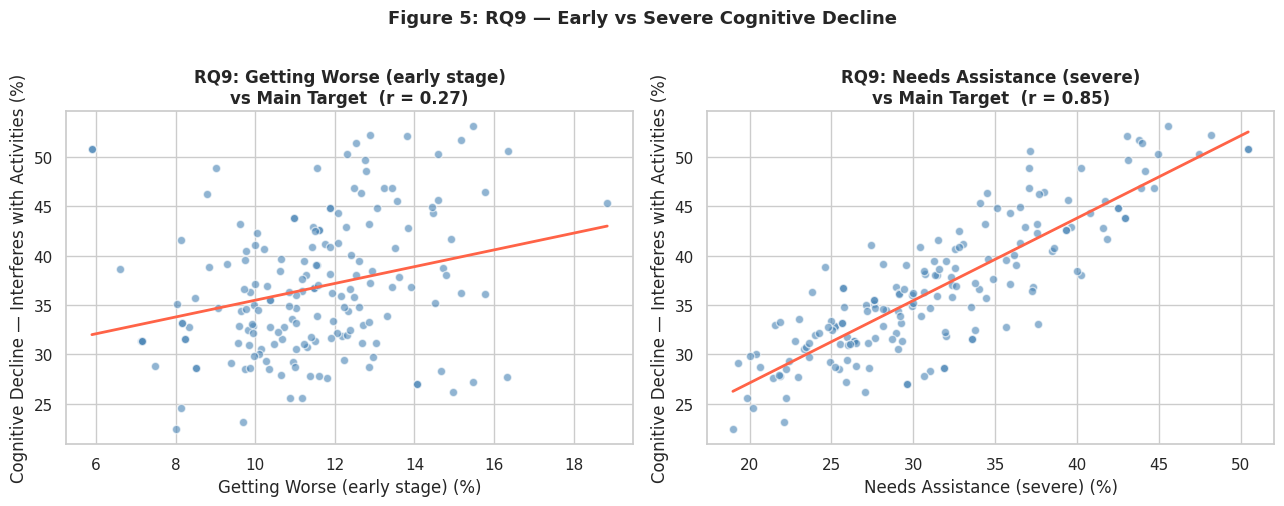

In [ ]:
# Scatter plots: early-stage measures vs the main target
rq9 = pivot_cog[[target, q_worse, q_assistance]].dropna()
r1 = rq9[target].corr(rq9[q_worse])
r2 = rq9[target].corr(rq9[q_assistance])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, r, label in [
    (axes[0], q_worse, r1, "Getting Worse (early stage)"),
    (axes[1], q_assistance, r2, "Needs Assistance (severe)")
]:
    ax.scatter(rq9[col], rq9[target], color='steelblue', alpha=0.6, edgecolor='white')
    m, b = np.polyfit(rq9[col], rq9[target], 1)
    x_line = np.linspace(rq9[col].min(), rq9[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)
    ax.set_xlabel(label + ' (%)')
    ax.set_ylabel('Cognitive Decline — Interferes with Activities (%)')
    ax.set_title(f'RQ9: {label}\nvs Main Target  (r = {r:.2f})', fontweight='bold')

plt.suptitle('Figure 5: RQ9 — Early vs Severe Cognitive Decline', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part 9: RQ2–RQ5 — Health Risk Factor Correlations

Here I look at how depression, physical inactivity, poor self-reported health, and disability relate to cognitive decline.

Note: correlations are calculated only for state-year rows where both variables have a value. For pairs where one is missing, that row is just skipped — no data is filled in.    
As we can see the numbers below, all six risk factors show a positive correlation with cognitive decline, meaning states where these health problems are more common also tend to have higher cognitive decline rates. Self-reported poor health (r = 0.54) and physical inactivity (r = 0.48) are the strongest predictors, suggesting that overall physical health and activity level play an important role. Mental distress (r = 0.44), disability (r = 0.43), and unhealthy days (r = 0.38) show moderate relationships. Depression has the weakest correlation (r = 0.22), which may be because this dataset measures lifetime diagnosis rather than current depression status, making it a less precise indicator of someone's present mental health condition.

In [ ]:
# Compute correlations — YearStart is not included since it's just a row label
corr_cols = [c for c in analysis_cols if c in pivot_clean.columns]
corr_matrix = pivot_clean[corr_cols].corr()

corr_with_target = corr_matrix[target].drop(target).sort_values(ascending=False)
corr_with_target.index = [short_names.get(i, i) for i in corr_with_target.index]

print("Correlation with Cognitive Decline (strongest to weakest):")
print(corr_with_target.round(3).to_string())

Correlation with Cognitive Decline (strongest to weakest):
Poor Health            0.541
Physical Inactivity    0.479
Mental Distress        0.442
Disability             0.432
Unhealthy Days         0.383
Depression             0.223


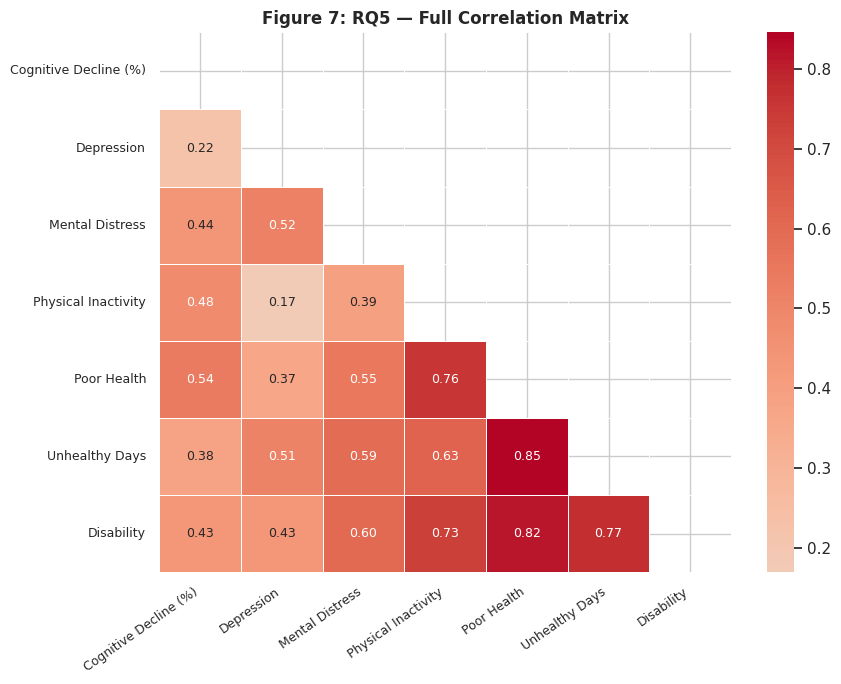

In [ ]:
# Full correlation heatmap — all variables together (supports RQ5)
cm_labeled = corr_matrix.copy()
cm_labeled.columns = [short_names.get(c, c) for c in cm_labeled.columns]
cm_labeled.index   = [short_names.get(c, c) for c in cm_labeled.index]

mask = np.triu(np.ones_like(cm_labeled, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_labeled, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Figure 7: RQ5 — Full Correlation Matrix', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.show()

Looking at the scatter plots (below), all six risk factors show a positive relationship with cognitive decline, meaning as each risk factor increases across states, cognitive decline tends to increase as well. Poor health (r=0.55) and mental distress (r=0.49) show the clearest upward trends, with the dots clustering relatively close to the trend line. Physical inactivity (r=0.47) and disability (r=0.45) show similar moderate-to-strong patterns. Unhealthy days (r=0.39) has a noticeable positive trend but with more spread around the line, meaning the relationship is less consistent across states. Depression (r=0.24) has the flattest trend line and the most scattered dots, confirming it is the weakest predictor, and states with high depression rates do not always have high cognitive decline rates. This may be because the depression variable measures lifetime diagnosis rather than current status, making it a less precise reflection of present mental health conditions.

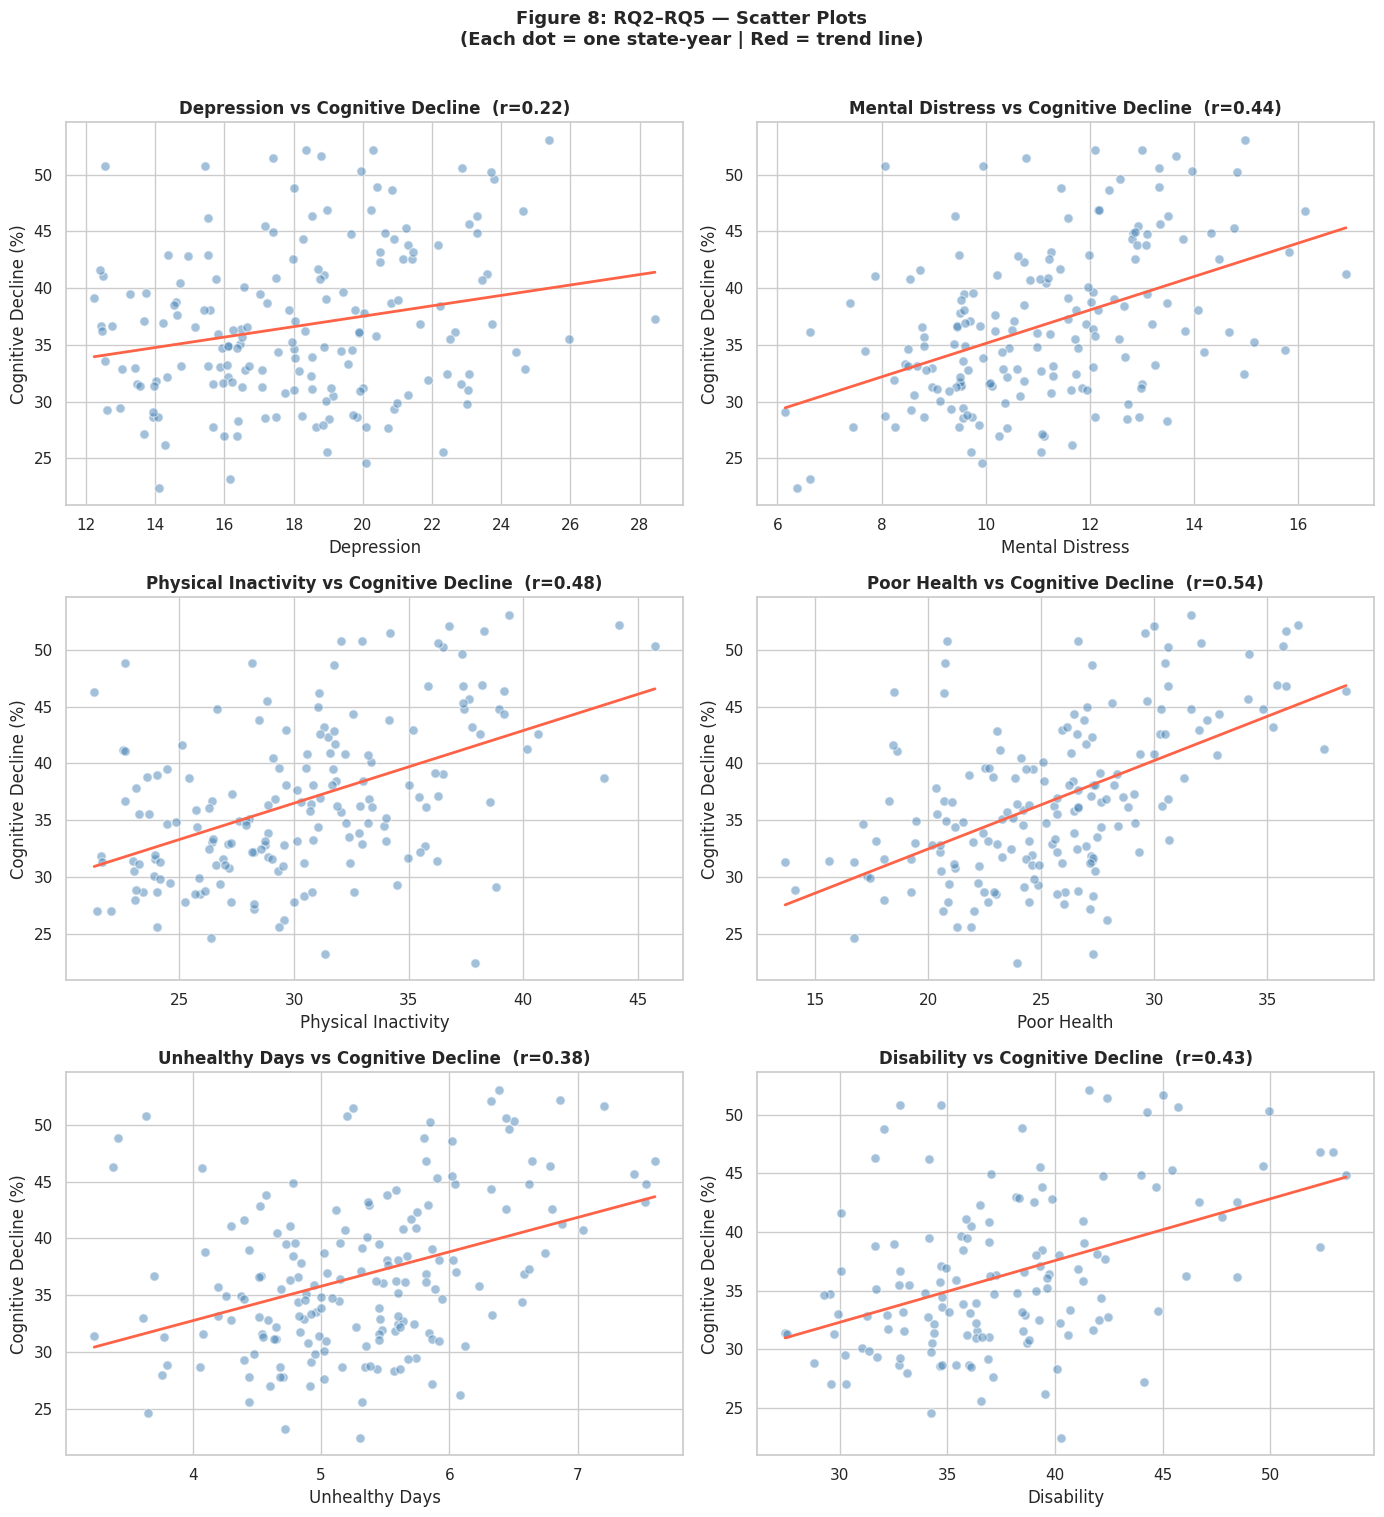

In [ ]:
# Scatter plots for each risk factor vs cognitive decline
risk_cols = [c for c in risk_factors if c in pivot_clean.columns]
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for i, col in enumerate(risk_cols):
    data = pivot_clean[[col, target]].dropna()
    x, y = data[col], data[target]
    r = x.corr(y)
    axes[i].scatter(x, y, color='steelblue', alpha=0.5, edgecolor='white', s=45)
    m, b = np.polyfit(x, y, 1)
    axes[i].plot(np.linspace(x.min(), x.max(), 100),
                 m * np.linspace(x.min(), x.max(), 100) + b, color='tomato', linewidth=2)
    axes[i].set_xlabel(short_names.get(col, col))
    axes[i].set_ylabel('Cognitive Decline (%)')
    axes[i].set_title(f'{short_names.get(col, col)} vs Cognitive Decline  (r={r:.2f})', fontweight='bold')

plt.suptitle('Figure 8: RQ2–RQ5 — Scatter Plots\n(Each dot = one state-year | Red = trend line)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part 10: Census API Data — RQ6 and RQ7

For RQ6 and RQ7 I need income and education data by state, which is
not in the CDC dataset. I'm pulling this from the U.S. Census Bureau
using their free public API. This is an example of live data ingestion, the data is pulled directly from a source rather than loaded from
a downloaded file.

Data source: U.S. Census Bureau, American Community Survey (ACS)
Dataset: ACS 5-Year Estimates, 2022
Variables:
  - DP03_0062E  = Median household income in dollars
  - DP02_0068PE = % of adults 25+ with a bachelor's degree or higher

No API key is needed, Census data is free and publicly available.

In [ ]:
import requests
from pprint import pprint

In [ ]:
# Define the API URLs — one for income, one for education
# Breaking down the URL:
#   api.census.gov/data/2022/acs/acs5/profile = ACS 5-year data, 2022
#   ?get=NAME,DP03_0062E = get state name + median income
#   &for=state:* = for all states

url_income = (
    "https://api.census.gov/data/2022/acs/acs5/profile"
    "?get=NAME,DP03_0062E&for=state:*"
)
url_edu = (
    "https://api.census.gov/data/2022/acs/acs5/profile"
    "?get=NAME,DP02_0068PE&for=state:*"
)
print("Tip: paste either URL into your browser to preview the raw data!")

Tip: paste either URL into your browser to preview the raw data!


In [ ]:
# Make the requests and check they worked
response_income = requests.get(url_income)
response_edu    = requests.get(url_edu)

if response_income.status_code == 200:
    print("Income data: request successful")
else:
    print(f"Income request failed. Status code: {response_income.status_code}")

if response_edu.status_code == 200:
    print("Education data: request successful")
else:
    print(f"Education request failed. Status code: {response_edu.status_code}")

Income data: request successful
Education data: request successful


In [ ]:
# Look at the raw JSON to understand the structure
# First row is always the headers, the rest are states
data_income = response_income.json()
print("Raw income data (first 4 rows):")
pprint(data_income[:4])

Raw income data (first 4 rows):
[['NAME', 'DP03_0062E', 'state'],
 ['Alabama', '59609', '01'],
 ['Alaska', '86370', '02'],
 ['Arizona', '72581', '04']]


In [ ]:
# Convert JSON to DataFrames and rename columns
data_edu = response_edu.json()

income_df = pd.DataFrame(data_income[1:], columns=data_income[0])
edu_df    = pd.DataFrame(data_edu[1:],    columns=data_edu[0])

income_df = income_df.rename(columns={"DP03_0062E": "Median_Income"})
edu_df    = edu_df.rename(columns={"DP02_0068PE":   "Pct_Bachelors"})

# Convert to numbers — the API returns everything as text
income_df["Median_Income"] = pd.to_numeric(income_df["Median_Income"], errors="coerce")
edu_df["Pct_Bachelors"]    = pd.to_numeric(edu_df["Pct_Bachelors"],    errors="coerce")

print("Income data sample:")
display(income_df[["NAME", "Median_Income"]].head(5))
print("\nEducation data sample:")
display(edu_df[["NAME", "Pct_Bachelors"]].head(5))

Income data sample:


,NAME,Median_Income
0,Alabama,59609
1,Alaska,86370
2,Arizona,72581
3,Arkansas,56335
4,California,91905



Education data sample:


,NAME,Pct_Bachelors
0,Alabama,27.2
1,Alaska,30.7
2,Arizona,31.8
3,Arkansas,24.7
4,California,35.9


In [ ]:
# Check missing values
print("Missing values:")
print(f"  Median Income: {income_df['Median_Income'].isna().sum()}")
print(f"  Pct Bachelors: {edu_df['Pct_Bachelors'].isna().sum()}")

Missing values:
  Median Income: 0
  Pct Bachelors: 1


In [ ]:
# Merge income and education into one Census dataframe
census_df = income_df[["NAME", "Median_Income"]].merge(
    edu_df[["NAME", "Pct_Bachelors"]], on="NAME"
)

# Add state abbreviations to match our CDC data
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT",
    "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND",
    "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

census_df["LocationAbbr"] = census_df["NAME"].map(state_abbrev)
census_df = census_df.dropna(subset=["LocationAbbr"])

print(f"Census dataset ready: {len(census_df)} states")
display(census_df.head())

Census dataset ready: 51 states


,NAME,Median_Income,Pct_Bachelors,LocationAbbr
0,Alabama,59609,27.2,AL
1,Alaska,86370,30.7,AK
2,Arizona,72581,31.8,AZ
3,Arkansas,56335,24.7,AR
4,California,91905,35.9,CA


In [ ]:
# Get one average cognitive decline value per state from CDC data
state_cog = (
    pivot_clean
    .groupby(["LocationAbbr", "LocationDesc"])[target]
    .mean()
    .reset_index()
)
state_cog.columns = ["LocationAbbr", "LocationDesc", "Avg_Cognitive_Decline"]

# Merge with Census data
merged = state_cog.merge(census_df, on="LocationAbbr", how="inner")

print(f"Final merged dataset: {len(merged)} states")
display(merged.head())

Final merged dataset: 51 states


,LocationAbbr,LocationDesc,Avg_Cognitive_Decline,NAME,Median_Income,Pct_Bachelors
0,AK,Alaska,30.847222,Alaska,86370,30.7
1,AL,Alabama,47.650000,Alabama,59609,27.2
2,AR,Arkansas,45.350000,Arkansas,56335,24.7
3,AZ,Arizona,32.951667,Arizona,72581,31.8
4,CA,California,36.512500,California,91905,35.9


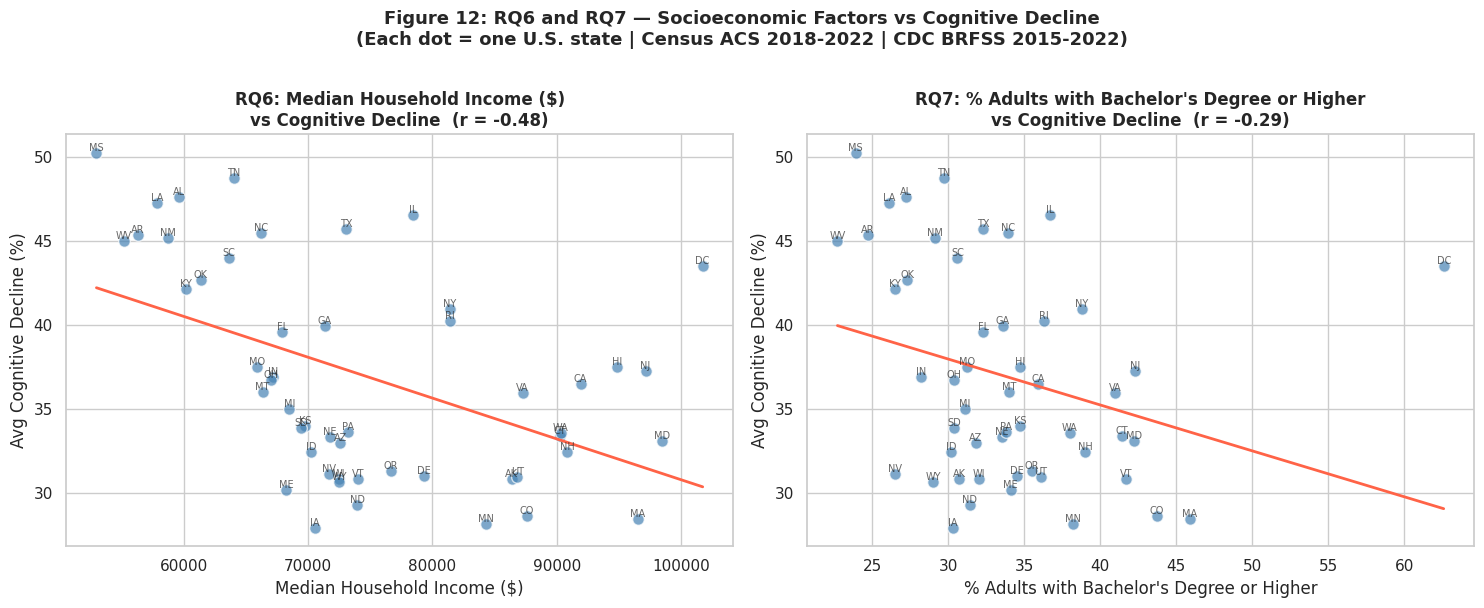

RQ6 - Income vs cognitive decline:    r = -0.476
RQ7 - Education vs cognitive decline: r = -0.289


In [ ]:
# Scatter plots for RQ6 and RQ7
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, xlabel, rq in [
    (axes[0], "Median_Income", "Median Household Income ($)", "RQ6"),
    (axes[1], "Pct_Bachelors", "% Adults with Bachelor's Degree or Higher", "RQ7")
]:
    x = merged[col]
    y = merged["Avg_Cognitive_Decline"]
    r = x.corr(y)

    ax.scatter(x, y, color='steelblue', alpha=0.7, edgecolor='white', s=70)

    for _, row in merged.iterrows():
        ax.annotate(row["LocationAbbr"],
                    (row[col], row["Avg_Cognitive_Decline"]),
                    fontsize=7, ha='center', va='bottom', alpha=0.7)

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Avg Cognitive Decline (%)")
    ax.set_title(f"{rq}: {xlabel}\nvs Cognitive Decline  (r = {r:.2f})",
                 fontweight='bold')

plt.suptitle(
    "Figure 12: RQ6 and RQ7 — Socioeconomic Factors vs Cognitive Decline\n"
    "(Each dot = one U.S. state | Census ACS 2018-2022 | CDC BRFSS 2015-2022)",
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

r6 = merged["Median_Income"].corr(merged["Avg_Cognitive_Decline"])
r7 = merged["Pct_Bachelors"].corr(merged["Avg_Cognitive_Decline"])
print(f"RQ6 - Income vs cognitive decline:    r = {r6:.3f}")
print(f"RQ7 - Education vs cognitive decline: r = {r7:.3f}")

## Part 10: Census API Data — RQ6 and RQ7

For RQ6 and RQ7 I need income and education data by state, which is
not in the CDC dataset. I'm pulling this from the U.S. Census Bureau
using their free public API. This is an example of live data ingestion
— the data is pulled directly from a source rather than loaded from
a downloaded file.

Data source: U.S. Census Bureau, American Community Survey (ACS)
Dataset: ACS 5-Year Estimates, 2022
Variables:
  - DP03_0062E  = Median household income in dollars
  - DP02_0068PE = % of adults 25+ with a bachelor's degree or higher

No API key is needed — Census data is free and publicly available.

In [ ]:
import requests
from pprint import pprint

In [ ]:
# Define the API URLs — one for income, one for education
# Breaking down the URL:
#   api.census.gov/data/2022/acs/acs5/profile = ACS 5-year data, 2022
#   ?get=NAME,DP03_0062E = get state name + median income
#   &for=state:* = for all states

url_income = (
    "https://api.census.gov/data/2022/acs/acs5/profile"
    "?get=NAME,DP03_0062E&for=state:*"
)
url_edu = (
    "https://api.census.gov/data/2022/acs/acs5/profile"
    "?get=NAME,DP02_0068PE&for=state:*"
)
print("Tip: paste either URL into your browser to preview the raw data!")

Tip: paste either URL into your browser to preview the raw data!


In [ ]:
# Make the requests and check they worked
response_income = requests.get(url_income)
response_edu    = requests.get(url_edu)

if response_income.status_code == 200:
    print("Income data: request successful")
else:
    print(f"Income request failed. Status code: {response_income.status_code}")

if response_edu.status_code == 200:
    print("Education data: request successful")
else:
    print(f"Education request failed. Status code: {response_edu.status_code}")

Income data: request successful
Education data: request successful


In [ ]:
# Look at the raw JSON to understand the structure
# First row is always the headers, the rest are states
data_income = response_income.json()
print("Raw income data (first 4 rows):")
pprint(data_income[:4])

Raw income data (first 4 rows):
[['NAME', 'DP03_0062E', 'state'],
 ['Alabama', '59609', '01'],
 ['Alaska', '86370', '02'],
 ['Arizona', '72581', '04']]


In [ ]:
# Convert JSON to DataFrames and rename columns
data_edu = response_edu.json()

income_df = pd.DataFrame(data_income[1:], columns=data_income[0])
edu_df    = pd.DataFrame(data_edu[1:],    columns=data_edu[0])

income_df = income_df.rename(columns={"DP03_0062E": "Median_Income"})
edu_df    = edu_df.rename(columns={"DP02_0068PE":   "Pct_Bachelors"})

# Convert to numbers — the API returns everything as text
income_df["Median_Income"] = pd.to_numeric(income_df["Median_Income"], errors="coerce")
edu_df["Pct_Bachelors"]    = pd.to_numeric(edu_df["Pct_Bachelors"],    errors="coerce")

print("Income data sample:")
display(income_df[["NAME", "Median_Income"]].head(5))
print("\nEducation data sample:")
display(edu_df[["NAME", "Pct_Bachelors"]].head(5))

Income data sample:


,NAME,Median_Income
0,Alabama,59609
1,Alaska,86370
2,Arizona,72581
3,Arkansas,56335
4,California,91905



Education data sample:


,NAME,Pct_Bachelors
0,Alabama,27.2
1,Alaska,30.7
2,Arizona,31.8
3,Arkansas,24.7
4,California,35.9


In [ ]:
# Check missing values
print("Missing values:")
print(f"  Median Income: {income_df['Median_Income'].isna().sum()}")
print(f"  Pct Bachelors: {edu_df['Pct_Bachelors'].isna().sum()}")

Missing values:
  Median Income: 0
  Pct Bachelors: 1


In [ ]:
# Merge income and education into one Census dataframe
census_df = income_df[["NAME", "Median_Income"]].merge(
    edu_df[["NAME", "Pct_Bachelors"]], on="NAME"
)

# Add state abbreviations to match our CDC data
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT",
    "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND",
    "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

census_df["LocationAbbr"] = census_df["NAME"].map(state_abbrev)
census_df = census_df.dropna(subset=["LocationAbbr"])

print(f"Census dataset ready: {len(census_df)} states")
display(census_df.head())

Census dataset ready: 51 states


,NAME,Median_Income,Pct_Bachelors,LocationAbbr
0,Alabama,59609,27.2,AL
1,Alaska,86370,30.7,AK
2,Arizona,72581,31.8,AZ
3,Arkansas,56335,24.7,AR
4,California,91905,35.9,CA


In [ ]:
# Get one average cognitive decline value per state from CDC data
state_cog = (
    pivot_clean
    .groupby(["LocationAbbr", "LocationDesc"])[target]
    .mean()
    .reset_index()
)
state_cog.columns = ["LocationAbbr", "LocationDesc", "Avg_Cognitive_Decline"]

# Merge with Census data
merged = state_cog.merge(census_df, on="LocationAbbr", how="inner")

print(f"Final merged dataset: {len(merged)} states")
display(merged.head())

Final merged dataset: 51 states


,LocationAbbr,LocationDesc,Avg_Cognitive_Decline,NAME,Median_Income,Pct_Bachelors
0,AK,Alaska,30.847222,Alaska,86370,30.7
1,AL,Alabama,47.650000,Alabama,59609,27.2
2,AR,Arkansas,45.350000,Arkansas,56335,24.7
3,AZ,Arizona,32.951667,Arizona,72581,31.8
4,CA,California,36.512500,California,91905,35.9


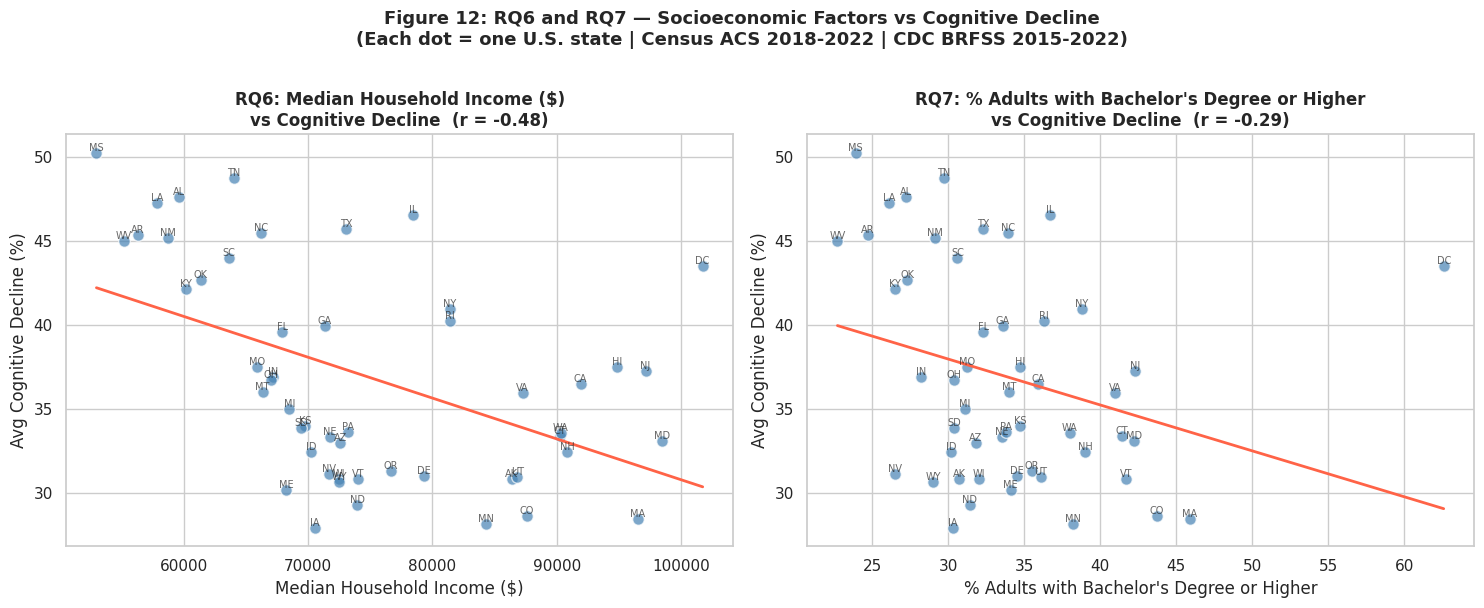

RQ6 - Income vs cognitive decline:    r = -0.476
RQ7 - Education vs cognitive decline: r = -0.289


In [ ]:
# Scatter plots for RQ6 and RQ7
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, xlabel, rq in [
    (axes[0], "Median_Income", "Median Household Income ($)", "RQ6"),
    (axes[1], "Pct_Bachelors", "% Adults with Bachelor's Degree or Higher", "RQ7")
]:
    x = merged[col]
    y = merged["Avg_Cognitive_Decline"]
    r = x.corr(y)

    ax.scatter(x, y, color='steelblue', alpha=0.7, edgecolor='white', s=70)

    for _, row in merged.iterrows():
        ax.annotate(row["LocationAbbr"],
                    (row[col], row["Avg_Cognitive_Decline"]),
                    fontsize=7, ha='center', va='bottom', alpha=0.7)

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Avg Cognitive Decline (%)")
    ax.set_title(f"{rq}: {xlabel}\nvs Cognitive Decline  (r = {r:.2f})",
                 fontweight='bold')

plt.suptitle(
    "Figure 12: RQ6 and RQ7 — Socioeconomic Factors vs Cognitive Decline\n"
    "(Each dot = one U.S. state | Census ACS 2018-2022 | CDC BRFSS 2015-2022)",
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

r6 = merged["Median_Income"].corr(merged["Avg_Cognitive_Decline"])
r7 = merged["Pct_Bachelors"].corr(merged["Avg_Cognitive_Decline"])
print(f"RQ6 - Income vs cognitive decline:    r = {r6:.3f}")
print(f"RQ7 - Education vs cognitive decline: r = {r7:.3f}")

Both income and education show negative correlations with cognitive decline, meaning states with higher income and more college graduates tend to have lower cognitive decline rates. Income has the stronger relationship (r = -0.48), where states like Mississippi, Louisiana, and Alabama have both low income and high cognitive decline, while states like Maryland and Massachusetts have high income and low cognitive decline. Education shows a weaker but still noticeable negative relationship (r = -0.29), with more scattered dots around the trend line, meaning education alone does not predict cognitive decline as consistently as income does. One interesting outlier is Washington D.C., which has high income and high education but still shows a relatively high cognitive decline rate, possibly because D.C. has very high income inequality and the averages do not reflect the full picture. Overall, these results suggest that the socioeconomic environment of a state plays a role in cognitive decline rates, with wealthier states tending to have better health outcomes for older adults.